In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression

In [2]:
# Load all three days
days = [-2, -1, 0]
dfs = []
for d in days:
    df = pd.read_csv(f'../data/prices_round_1_day_{d}.csv', sep=';')
    dfs.append(df)

prices = pd.concat(dfs, ignore_index=True)
prices = prices[prices["mid_price"] > 0]

# Create a continuous x-axis: each day has timestamps 0..999900 (step 100)
# Map day -2 -> 0, day -1 -> 1, day 0 -> 2, then offset by day_index * 1_000_000
day_offset = {-2: 0, -1: 1_000_000, 0: 2_000_000}
prices['time'] = prices['day'].map(day_offset) + prices['timestamp']

products = prices['product'].unique()
print('Products found:', products)

Products found: ['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']


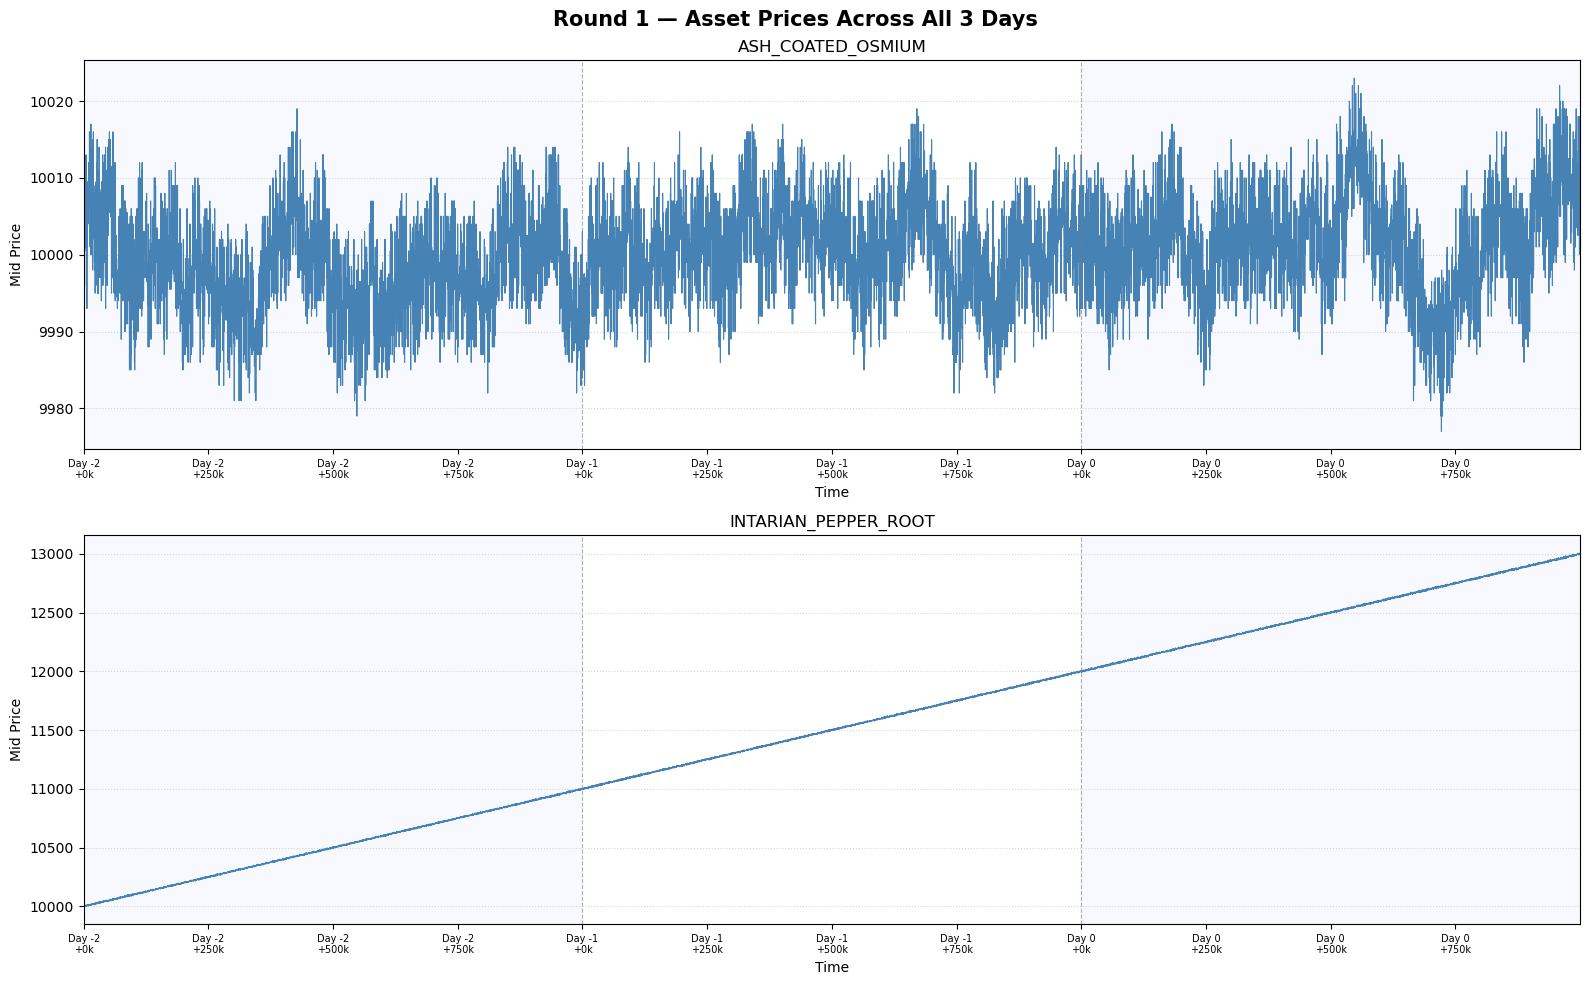

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)
fig.suptitle('Round 1 — Asset Prices Across All 3 Days', fontsize=15, fontweight='bold')

day_boundaries = [0, 1_000_000, 2_000_000]
day_labels = ['Day -2', 'Day -1', 'Day 0']

for ax, product in zip(axes, sorted(products)):
    subset = prices[prices['product'] == product].sort_values('time')
    ax.plot(subset['time'], subset['mid_price'], linewidth=0.8, color='steelblue')

    # Shade alternate days for readability
    day_spans = [
        (0,        1_000_000),
        (1_000_000, 2_000_000),
        (2_000_000, 3_000_000),
    ]
    colors = ['#f0f4ff', '#ffffff', '#f0f4ff']
    for (start, end), col in zip(day_spans, colors):
        ax.axvspan(start, end, alpha=0.5, color=col, zorder=0)

    # Vertical lines at day boundaries
    for b in day_boundaries[1:]:
        ax.axvline(b, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

    # Custom x-tick labels showing day + relative timestamp
    tick_positions = [d + t for d in day_boundaries for t in [0, 250_000, 500_000, 750_000]]
    tick_labels = [f'{dl}\n+{t//1000}k' for dl, d in zip(day_labels, day_boundaries)
                   for t in [0, 250_000, 500_000, 750_000]]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=7)

    ax.set_title(product, fontsize=12)
    ax.set_ylabel('Mid Price')
    ax.set_xlabel('Time')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.set_xlim(0, 3_000_000)

plt.tight_layout()
plt.show()

In [6]:
df = pd.read_csv("data/prices_round_1_day_-2.csv", delimiter=";")
df[df["mid_price"] == 0]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
676,-2,33800,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
876,-2,43800,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1115,-2,55700,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1966,-2,98300,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2194,-2,109700,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3311,-2,165500,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3474,-2,173700,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3781,-2,189000,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4510,-2,225500,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4915,-2,245700,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [25]:
subset = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].sort_values('time')
time = subset['timestamp'].to_numpy().reshape(-1, 1)
mid_price = subset['mid_price'].to_numpy().reshape(-1, 1)

model = LinearRegression()
model.fit(time, mid_price)
model.coef_


array([[0.00100091]])